# CPA attack on AES software implementation

This notebook performs the **CPA attack** on the previously acquired power traces.  
It loads the `.cwp` traceset produced by the acquisition notebook and computes:

- **Correlation Power Analysis (CPA)** results  
- **Partial Guessing Entropy (PGE)** vs. number of traces  
- **Correlation trends** for each key byte, comparing correct vs. wrong key hypotheses  

These plots help evaluate the **difficulty of recovering each key byte** and visualize the leakage behavior across the trace window.

⚠️ **Important:**  
This notebook assumes that the **Power Trace Acquisition** notebook (`xheep_capture_AES.ipynb`) has already been executed and that a valid `.cwp` project file is available.


In [1]:
import sys
import os
import time
from pathlib import Path

## Project paths
This block robustly detects the project root (`DOJO_ROOT`) starting from either the script location (`__file__`) or the current working directory (for notebooks). From there it defines all relevant subdirectories (AES sources, SCA scripts, X-HEEP, traces, plots, cache), ensures output folders exist, and adds the local source paths to `sys.path` .

In [2]:
from pathlib import Path

def find_project_root(start: Path, markers=("fusesoc.conf", ".dojo_root")) -> Path:
    current = start
    while current != current.parent:
        if any((current / m).exists() for m in markers):
            return current
        current = current.parent

    raise RuntimeError(
        f"Could not find project root (looked for markers: {markers}). "
        "Please ensure you are inside the Side-Channel-Dojo repository."
    )

# In a script, __file__ exists; in a notebook, it does not.
try:
    SCRIPT_DIR = Path(__file__).resolve().parent
except NameError:
    # Notebook / interactive: use the current working directory instead
    SCRIPT_DIR = Path.cwd()

DOJO_ROOT = find_project_root(SCRIPT_DIR)

AES_PY_DIR   = DOJO_ROOT / "sw" / "ciphers" / "AES_python"
SCA_DIR      = DOJO_ROOT / "sw" / "sca_scripts"
HW_DIR       = DOJO_ROOT / "hw"

# Specific sub-dirs used by this script
XHEEP_DIR           = DOJO_ROOT / "sw" / "x-heep"
TRACESET_DIR        = DOJO_ROOT / "sw" / "traceset" / "AES" / "sw"
BASE_PLOT_DIR       = DOJO_ROOT / "sw" / "sca_scripts" / "AES" / "sw" / "plot" 
BASE_CACHE_DIR      = DOJO_ROOT / "sw" / "sca_scripts" / "AES" / "sw" / "cache" 

# Ensure traceset and plot directories exist
TRACESET_DIR.mkdir(parents=True, exist_ok=True)

# Make local modules importable without fragile ../ relative paths
sys.path.insert(0, str(AES_PY_DIR))
sys.path.insert(0, str(SCA_DIR))
sys.path.insert(0, str(XHEEP_DIR))

## Imports

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
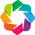

In [3]:
import chipwhisperer as cw
import chipwhisperer.analyzer as cwa

from tqdm import tqdm
from analyzer.attack.aes.SBox_leakage_models import AES128SboxResistantLeakageModels
from analyzer.attack.aes.key_schedule import key_schedule_rounds

import holoviews as hv
hv.extension("bokeh")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import logging
import json

## Initialization

In [4]:
# Available S-box implementations
AVAILABLE_SBOXES = [
    "sbox_rijandael  (default AES S-Box, aes_sbox)",
    "sbox_freyre_1",
    "sbox_freyre_2",
    "sbox_freyre_3",
    "sbox_hussain_6",
    "sbox_ozkaynak_1"
]

# Default S-box to test
tested_sbox = "sbox_rijandael"
sbox_id = tested_sbox.replace("sbox_", "")

# Whether we are attacking a masked firmware or the plain S-box firmware
masked_flag = False

# ---------------------------------------------------------------------------
# Flow flags
# ---------------------------------------------------------------------------
# load correlation and PGE results 
load_attack_results = True
save_attack_results = True
# 
traces_pge_plot         = True   # Plot PGE vs traces
traces_correlation_plot = True   # Plot correlation vs traces
# Output control
save_plots              = True   # Save plots to disk
save_results            = True   # Save analysis results to disk

# ---------------------------------------------------------------------------
# Bitstream, defines, firmware, project, directories
# ---------------------------------------------------------------------------

# Firmware and project (.cwp) paths:
# - Firmware is under DOJO_ROOT/sw/x-heep
# - Project is under DOJO_ROOT/sw/traceset/AES/sw
if masked_flag:
    project_file_path = TRACESET_DIR / f"CW305_xheep_AES_{sbox_id}_masked.cwp"
else:
    project_file_path = TRACESET_DIR / f"CW305_xheep_AES_{sbox_id}.cwp"

project_file = str(project_file_path)
 
CACHE_DIR = BASE_CACHE_DIR / tested_sbox
PLOT_DIR = BASE_PLOT_DIR / tested_sbox
CPA_CACHE_FILE = CACHE_DIR / f"CPA_results_{tested_sbox}.json"

# Ensure traceset and plot directories exist
TRACESET_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------------------------
# Configuration printout
# ---------------------------------------------------------------------------

def _yn(flag: bool) -> str:
    """Return 'yes' or 'no' for a boolean flag."""
    return "yes" if flag else "no"


print("\n================= CONFIGURATION =================")
print(f"DOJO_ROOT           : {DOJO_ROOT}")
print()
print("Target")
print(f"  Tested S-box              : {tested_sbox}")
print(f"  Masked firmware           : {_yn(masked_flag)}")
print()
print("Paths")
print(f"  CW project (.cwp)         : {project_file}")
print(f"  Traceset dir              : {TRACESET_DIR}")
print(f"  Plot dir                  : {PLOT_DIR}")
print(f"  Cache dir                 : {CACHE_DIR}")
print()
print("Analysis configuration")
print(f"  Save plots                : {_yn(save_plots)}")
print(f"  Save results              : {_yn(save_results)}")
print(f"  Load CPA results (cache)  : {_yn(load_attack_results)}")
print(f"  Save CPA results (cache)  : {_yn(save_attack_results)}")
print()
print(f"  PGE plot                  : {_yn(traces_pge_plot)}")
print(f"  Correlation plot          : {_yn(traces_correlation_plot)}")
print("=================================================\n")



================= CONFIGURATION =================
DOJO_ROOT           : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo

Target
  Tested S-box              : sbox_rijandael
  Masked firmware           : no

Paths
  CW project (.cwp)         : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/traceset/AES/sw/CW305_xheep_AES_rijandael.cwp
  Traceset dir              : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/traceset/AES/sw
  Plot dir                  : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/sca_scripts/AES/sw/plot/sbox_rijandael
  Cache dir                 : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/sca_scripts/AES/sw/cache/sbox_rijandael

Analysis configuration
  Save plots                : yes
  Save results              : yes
  Load CPA results (cache)  : yes
  Save CPA results (cache)  : yes

  PGE plot                  : yes
  Correlation plot          : yes



## Opening the ChipWhisperer Analyzer (CWA) Project

This notebook uses the **ChipWhisperer Analyzer (CWA)** framework to perform offline side-channel analysis on previously captured traces.  
A CWA *project* (`.cwp` file) bundles together:

- **Power traces** (waveforms)
- **Associated metadata** (keys, plaintexts/ciphertexts, trace labels)
- **Analysis functions** (CPA, PGE, SNR, etc.)

Here, we load the CWA project generated during the trace acquisition phase and run CPA attack based on the tested S-box and calculate PGE and correlation trends to evaluate how much information about the secret key leaks from the measured power consumption.

In [5]:
try:
    # Open the project for CPA analysis
    project = cw.open_project(project_file)
    print(f"[ANALYSIS] Loaded project file: {project_file}")
except Exception as e:
    print(f"[ERROR] Failed to open project file '{project_file}': {e}")

    # If the file does not exist, give a clear hint about the capture notebook
    if not Path(project_file).exists():
        print(
            "[HINT] The ChipWhisperer project file does not exist.\n"
            "       Make sure you have run the power-trace capture notebook "
            "'xheep_capture_AES.ipynb' (or the equivalent capture script) first."
        )

    # Re-raise so the notebook stops instead of continuing with an invalid state
    raise

[ANALYSIS] Loaded project file: /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/traceset/AES/sw/CW305_xheep_AES_rijandael.cwp


## CPA Attack

- simple JSON-based cache helpers to save/load correlation and PGE trends of the attack 

In [6]:
def save_cpa_results(x_axis,
                     pge_per_byte,
                     corr_correct,
                     corr_wrong_max,
                     filename,
                     meta=None):
    """
    Save PGE and correlation trends for each subkey to a JSON file.

    Stored data:
      - x_axis: trace indices (shared for all bytes)
      - pge[byte]: PGE vs traces
      - corr_correct[byte]: correlation curve of correct key guess
      - corr_wrong_max[byte]: max correlation over all wrong key guesses
    """
    if meta is None:
        meta = {}

    data = {
        "x_axis": list(x_axis),
        "pge": [list(p) for p in pge_per_byte],
        "corr_correct": corr_correct,
        "corr_wrong_max": corr_wrong_max,
        "meta": meta,
    }

    os.makedirs(os.path.dirname(filename), exist_ok=True)
    with open(filename, "w") as f:
        json.dump(data, f, indent=2)


def load_cpa_results(filename):
    """
    Load PGE and correlation curves for each subkey from a JSON file.

    Returns:
        x_axis: numpy array (int)
        pge_per_byte: list of numpy arrays
        corr_correct: list of numpy arrays
        corr_wrong_max: list of numpy arrays
        meta: dict
    """
    with open(filename, "r") as f:
        data = json.load(f)

    x_axis = np.array(data["x_axis"], dtype=np.int64)
    pge_per_byte = [np.array(p, dtype=np.float64) for p in data["pge"]]
    corr_correct = [np.array(c, dtype=np.float64) for c in data["corr_correct"]]
    corr_wrong_max = [np.array(c, dtype=np.float64) for c in data["corr_wrong_max"]]
    meta = data.get("meta", {})

    return x_axis, pge_per_byte, corr_correct, corr_wrong_max, meta


- ChipWhisperer CPA callback (`get_python_callback` / `_default_python_callback`) that tracks iterations and prepares PGE-related statistics
- helper (`to_hex_str`) to pretty-print byte sequences in hex.

In [7]:
def _default_python_callback(attack):
    """
    Default Python callback used by ChipWhisperer during CPA analysis.

    It extracts attack results, computes PGE, and can be extended to store
    intermediate statistics if needed.
    """
    global current_trace_iteration
    attack_results = attack.results
    key = attack.known_key()

    attack_results.set_known_key(key)
    stat_data = attack_results.find_maximums()
    df = pd.DataFrame(stat_data).transpose()

    # Add PGE row
    df_pge = (
        pd.DataFrame(attack_results.pge)
        .transpose()
        .rename(index={0: "PGE="}, columns=int)
    )
    df = pd.concat([df_pge, df], ignore_index=False)

    reporting_interval = attack.reporting_interval
    tstart = current_trace_iteration * reporting_interval
    tend = tstart + reporting_interval
    current_trace_iteration += 1
    # (df, tstart, tend) could be stored or logged if needed


def get_python_callback(attack):
    """
    Wrap `_default_python_callback` into a closure that keeps track of
    the current trace iteration.
    """
    global current_trace_iteration
    current_trace_iteration = 0
    return lambda: _default_python_callback(attack)


# ---------------------------------------------------------------------------
# Utility functions
# ---------------------------------------------------------------------------
def byte_to_color(idx):
    """Map byte index to a color (Category20 palette)."""
    return hv.Palette.colormaps["Category20"](idx / 16.0)

def to_hex_str(x):
    """Format a bytes-like / iterable of ints as spaced lowercase hex."""
    return " ".join(f"{b:02x}" for b in x)

## CPA attack
This block runs the CPA attack and optionally caches its results.

- If `load_attack_results` is `True`, it first tries to load previously saved CPA data
  (PGE and correlation trends) from `CPA_CACHE_FILE`. If loading fails, it falls back
  to running the attack.
- If no cached data is used, it:
  - runs a CPA attack with the chosen AES leakage model,
  - recovers and verifies the key,
  - extracts, for each key byte, the PGE curve and the correlation curves
    (correct key vs. max over wrong keys),
  - and, if `save_attack_results` is `True`, stores these curves and some metadata
    in a JSON cache file for later reuse without re-running the attack.


In [8]:
if load_attack_results:
    try:
        (x_axis,
         pge_per_byte,
         corr_correct,
         corr_wrong_max,
         cpa_meta) = load_cpa_results(CPA_CACHE_FILE)
        key = cpa_meta['key']

        print(f"[ANALYSIS] Loaded cached CPA results from: {CPA_CACHE_FILE}")
    except FileNotFoundError:
        print(f"[WARN] CPA cache file not found at {CPA_CACHE_FILE}, running attack instead.")
        load_attack_results = False
    except Exception as e:
        print(f"[ERROR] Failed to load CPA cache from {CPA_CACHE_FILE}: {e}")
        load_attack_results = False

if not load_attack_results:
    print("Running CPA attack (this might take a while)...")
    leak_model = AES128SboxResistantLeakageModels().FirstRound_ModifiedSbox_Output(
        tested_sbox
    )
    attack = cwa.cpa(project, leak_model)
    results = attack.run(get_python_callback(attack))
    print("CPA attack finished. Results:")
    print(results)

    # Recover key from first-round key and key schedule
    recv_firstroundkey = [kguess[0][0] for kguess in results.find_maximums()]
    recv_key = key_schedule_rounds(recv_firstroundkey, 0, 0, tested_sbox)
    print("Recovered key: ", [hex(subkey) for subkey in recv_key])

    key = list(project.keys[0])
    if key != recv_key:
        logging.warning(
            "Failed to recover encryption key!\nGot {}\nExp {}\n".format(
                [hex(k) for k in recv_key], [hex(k) for k in key]
            )
        )
    else:
        print("Key recovery : Success!")

    # Extract PGE and correlation trends from ChipWhisperer results
    plot_data = cwa.analyzer_plots(results)

    # PGE per byte
    x_axis = plot_data.pge_vs_trace(0)[0]
    pge_per_byte = [plot_data.pge_vs_trace(i)[1] for i, _ in enumerate(key)]

    # Correlation curves per byte
    corr_correct = []
    corr_wrong_max = []

    for bnum, _ in enumerate(key):
        x_corr, corr_matrix = plot_data.corr_vs_trace(bnum)
        corr_matrix = np.array(corr_matrix)

        # Index of correct key guess for this byte
        correct_idx = results.known_key[bnum]

        # Correct key correlation curve
        corr_correct.append(corr_matrix[correct_idx].tolist())

        # Max over all wrong key guesses at each trace
        wrong_mask = [i != correct_idx for i in range(256)]
        wrong_results = corr_matrix[wrong_mask]
        corr_wrong_max.append(np.amax(wrong_results, axis=0).tolist())

        # Sanity check: x_axis should match x_corr
        if list(x_axis) != list(x_corr):
            raise RuntimeError("x_axis mismatch between PGE and correlation data")

    # Save CPA curves to cache if requested
    if save_attack_results:
        meta = {
            "tested_sbox": tested_sbox,
            "masked": masked_flag,
            "num_traces": len(project.traces),
            "key": [hex(k) for k in key],
            "recovered key": [hex(k) for k in recv_key],
        }
        save_cpa_results(x_axis, pge_per_byte, corr_correct, corr_wrong_max,CPA_CACHE_FILE, meta=meta)
        print(f"[ANALYSIS] CPA results cached to: {CPA_CACHE_FILE}")

[ANALYSIS] Loaded cached CPA results from: /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/sca_scripts/AES/sw/cache/sbox_rijandael/CPA_results_sbox_rijandael.json


### PGE vs Traces plot ###

Generating PGE vs Traces plot...


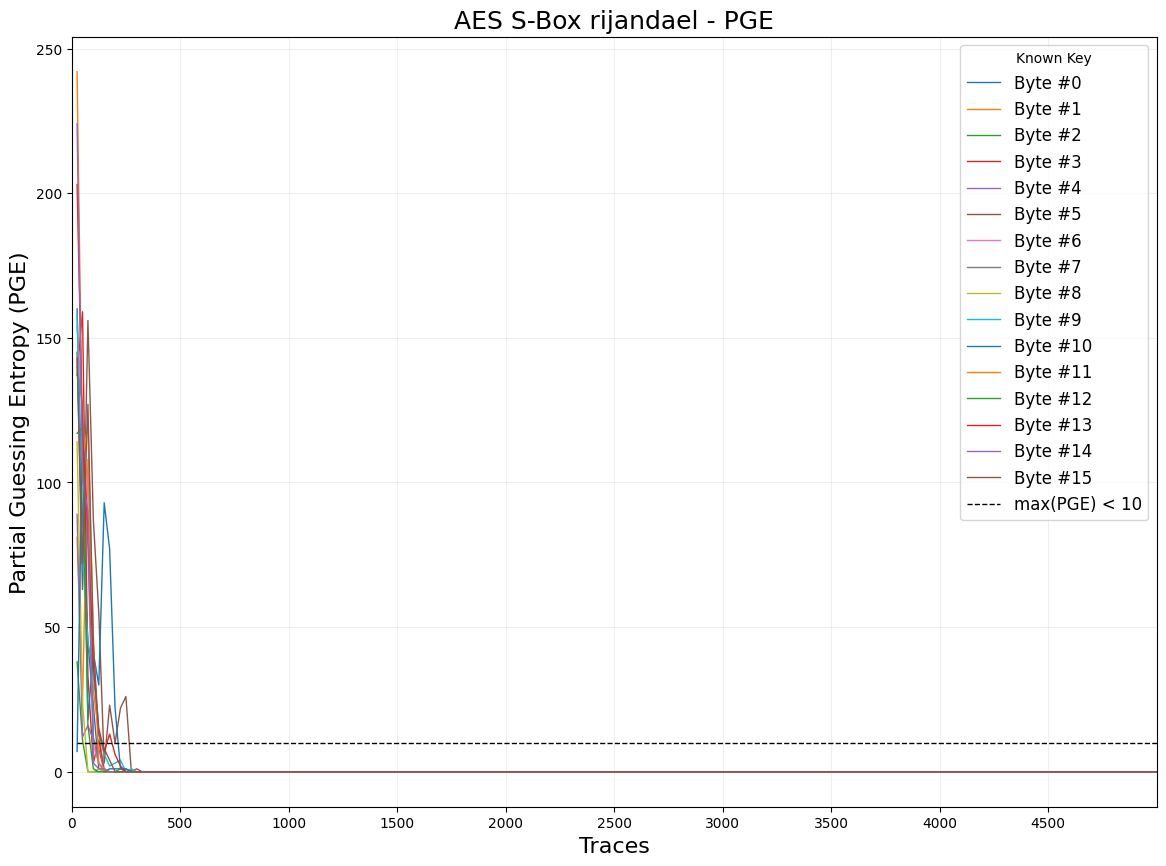

In [9]:
if traces_pge_plot:
    print("Generating PGE vs Traces plot...")
    """
    Plot PGE trends for all 16 key bytes with matplotlib.
    """

    fig, ax1 = plt.subplots(nrows=1, ncols=1, sharex=True, figsize=[14, 10])
    plt.grid(which="major", axis="both", alpha=0.2)

    step = 500

    # pge_per_byte[i] is a 1D array: PGE over traces for byte i
    for i, _ in enumerate(key):
        plt.plot(x_axis, pge_per_byte[i], linewidth=1, label=f"Byte #{i}")

    # Horizontal guideline at PGE = 10
    plt.plot(
        x_axis,
        [10] * len(x_axis),
        linewidth=1,
        linestyle="dashed",
        color="black",
        label="max(PGE) < 10",
    )

    plt.legend(title="Known Key", fontsize=12, loc="upper right")
    plt.title(f"AES S-Box {sbox_id} - PGE", fontsize=18)
    ax1.set_xticks(range(0, x_axis[-1], step))
    ax1.set_ylabel("Partial Guessing Entropy (PGE)", fontsize=16)
    ax1.set_xlabel("Traces", fontsize=16)
    ax1.set_xlim(0, x_axis[-1])

    out_file = (
        PLOT_DIR
        / (
            f"AES_masked_PGE_{tested_sbox}.png"
            if masked_flag
            else f"AES_PGE_{tested_sbox}.png"
        )
    )
    if save_plots:
        plt.savefig(out_file)

    plt.show()
    plt.close(fig)


### Correlation plot

Generating Correlation plot...


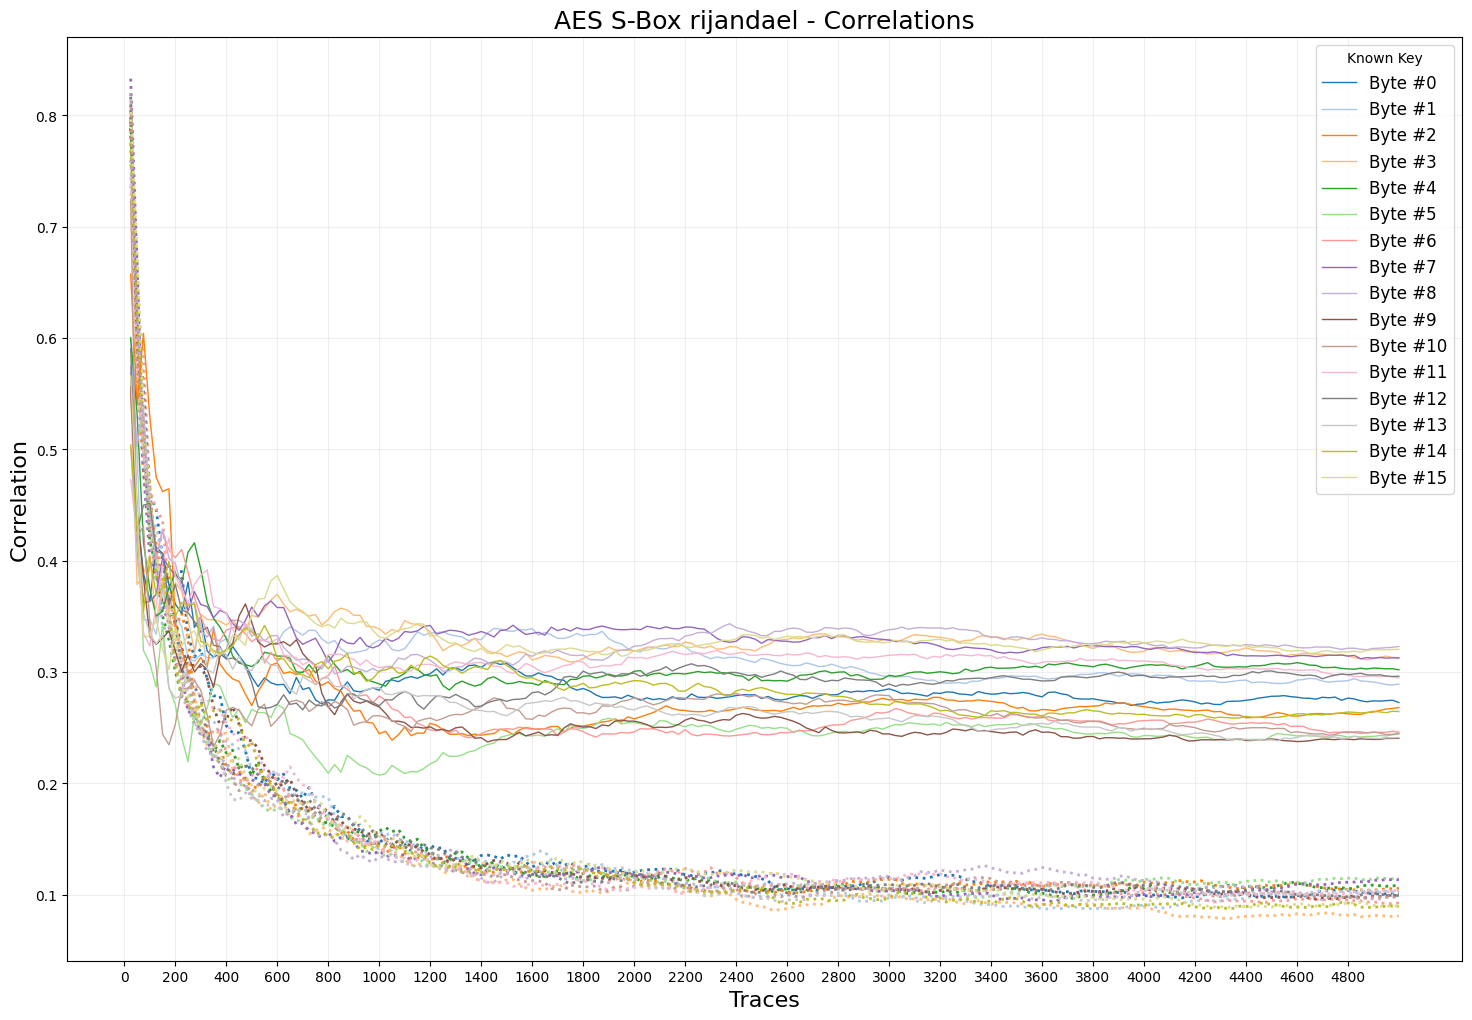

In [10]:
if traces_correlation_plot:
    print("Generating Correlation plot...")
    """
    Plot correlation trends of correct vs. wrong key guesses over traces,
    using precomputed / cached CPA results (corr_correct, corr_wrong_max).
    """

    # Number of key bytes inferred from cached CPA data
    bnum_it = range(len(corr_correct))

    fig, ax1 = plt.subplots(nrows=1, ncols=1, sharex=True, figsize=[18, 12])
    plt.grid(which="major", axis="both", alpha=0.2)

    # Plot correlation trends of wrong key guesses (max over all wrong keys)
    for bnum in bnum_it:
        ax1.plot(
            x_axis,
            corr_wrong_max[bnum],
            linewidth=2,
            linestyle="dotted",
            color=byte_to_color(bnum),
        )

    # Plot correct key guesses on top of wrong ones
    for bnum in bnum_it:
        ax1.plot(
            x_axis,
            corr_correct[bnum],
            linewidth=1,
            label=f"Byte #{bnum}",
            color=byte_to_color(bnum),
        )

    ax1.legend(title="Known Key", fontsize=12, loc="upper right")
    plt.title(f"AES S-Box {sbox_id} - Correlations", fontsize=18)

    step = 200
    ax1.set_xticks(range(0, x_axis[-1], step))
    ax1.set_ylabel("Correlation", fontsize=16)
    ax1.set_xlabel("Traces", fontsize=16)

    out_file = (
        PLOT_DIR
        / (
            f"AES_masked_correlations_{tested_sbox}.png"
            if masked_flag
            else f"AES_correlations_{tested_sbox}.png"
        )
    )
    if save_plots:
        plt.savefig(out_file)
    plt.show()  # enable if you want interactive display
    plt.close(fig)


In [11]:
project.close()